In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("Reviews.csv")

print(df.head())
print(df.columns)
print(df.info())


   Id   ProductId          UserId                      ProfileName  \
0   1  B001E4KFG0  A3SGXH7AUHU8GW                       delmartian   
1   2  B00813GRG4  A1D87F6ZCVE5NK                           dll pa   
2   3  B000LQOCH0   ABXLMWJIXXAIN  Natalia Corres "Natalia Corres"   
3   4  B000UA0QIQ  A395BORC6FGVXV                             Karl   
4   5  B006K2ZZ7K  A1UQRSCLF8GW1T    Michael D. Bigham "M. Wassir"   

   HelpfulnessNumerator  HelpfulnessDenominator  Score        Time  \
0                     1                       1      5  1303862400   
1                     0                       0      1  1346976000   
2                     1                       1      4  1219017600   
3                     3                       3      2  1307923200   
4                     0                       0      5  1350777600   

                 Summary                                               Text  
0  Good Quality Dog Food  I have bought several of the Vitality canned d...  
1 

In [3]:
df.dropna(inplace=True)

In [4]:
def get_sentiment(score):
    if score >= 4:
        return "positive"
    elif score == 3:
        return "neutral"
    else:
        return "negative"

df['sentiment'] = df['Score'].apply(get_sentiment)

In [5]:
print(df['sentiment'].value_counts())

positive    443766
negative     82007
neutral      42638
Name: sentiment, dtype: int64


In [6]:
df_positive = df[df['sentiment'] == 'positive'].sample(3000)
df_negative = df[df['sentiment'] == 'negative'].sample(3000)
df_neutral = df[df['sentiment'] == 'neutral'].sample(3000)

df = pd.concat([df_positive, df_negative, df_neutral])

In [7]:
import re
import nltk
from nltk.corpus import stopwords

nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^\w\s]', '', text)
    words = text.split()
    words = [word for word in words if word not in stop_words]
    return " ".join(words)

df['cleaned_text'] = df['Text'].apply(clean_text)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\renuk\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [8]:
print(df.head())

            Id   ProductId          UserId               ProfileName  \
298977  298978  B005CUKH6K  A382423XSF3N19           Pamela A. Moore   
95227    95228  B00401OZ1U  A1Y8C3OX94QXYG               JoAnn Toner   
515328  515329  B003DX141K   A4D2848CCTRK2                     Leigh   
535910  535911  B003VXHGDM  A1Z94P94HPWOU0  M. Williams "Lucasmommy"   
20552    20553  B003PFUNU4   AXE5IJE72616G               Beach Books   

        HelpfulnessNumerator  HelpfulnessDenominator  Score        Time  \
298977                     0                       0      4  1326326400   
95227                      2                       2      5  1296000000   
515328                     0                       0      4  1332288000   
535910                     6                       6      5  1283558400   
20552                      2                       4      5  1285891200   

                              Summary  \
298977  No real dark chocolate taste.   
95227                      Water S

In [9]:
print(df['sentiment'].value_counts())

positive    3000
negative    3000
neutral     3000
Name: sentiment, dtype: int64


In [10]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=5000)

X = vectorizer.fit_transform(df['cleaned_text'])
y = df['sentiment']

In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [12]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train, y_train)

C:\Users\renuk\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [13]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.6833333333333333
              precision    recall  f1-score   support

    negative       0.70      0.72      0.71       601
     neutral       0.62      0.60      0.61       614
    positive       0.73      0.74      0.74       585

    accuracy                           0.68      1800
   macro avg       0.68      0.68      0.68      1800
weighted avg       0.68      0.68      0.68      1800



In [14]:
def predict_sentiment(text):
    text = clean_text(text)
    vec = vectorizer.transform([text])
    return model.predict(vec)[0]

print(predict_sentiment("This product is amazing"))
print(predict_sentiment("Waste of money"))

positive
negative


In [15]:
aspects = {
    "quality": ["quality", "product", "material"],
    "delivery": ["delivery", "shipping", "late"],
    "price": ["price", "cost", "expensive", "cheap"]
}

In [16]:
def get_aspect_sentiment(text):
    text_clean = clean_text(text)
    result = {}

    for aspect, keywords in aspects.items():
        for word in keywords:
            if word in text_clean:
                vec = vectorizer.transform([text_clean])
                sentiment = model.predict(vec)[0]
                result[aspect] = sentiment
                break

    return result

In [17]:
print(get_aspect_sentiment("Good quality but delivery was late"))

{'quality': 'positive', 'delivery': 'positive'}


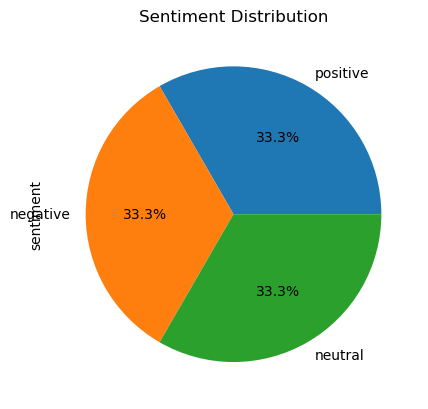

In [49]:
import matplotlib.pyplot as plt

df['sentiment'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title("Sentiment Distribution")
plt.show()

  Obtaining dependency information for streamlit from https://files.pythonhosted.org/packages/d8/1a/3ca2293d8552bacea3e67e9600d2d1df7df4a325059769ad83d91c279595/streamlit-1.57.0-py3-none-any.whl.metadata
  Obtaining dependency information for altair!=5.4.0,!=5.4.1,<7,>=4.0 from https://files.pythonhosted.org/packages/ce/63/5dacc8d8306c715088b897a479e551bc0779fd2f0f26c97fec5e36542b4e/altair-6.1.0-py3-none-any.whl.metadata
  Obtaining dependency information for blinker<2,>=1.5.0 from https://files.pythonhosted.org/packages/10/cb/f2ad4230dc2eb1a74edf38f1a38b9b52277f75bef262d8908e60d957e13c/blinker-1.9.0-py3-none-any.whl.metadata
  Obtaining dependency information for cachetools<8,>=5.5 from https://files.pythonhosted.org/packages/87/42/e09974bc74ea2791f985dff3d7f06065d11abcc31da6c46fc5f83046516e/cachetools-7.1.0-py3-none-any.whl.metadata
  Obtaining dependency information for gitpython!=3.1.19,<4,>=3.0.7 from https://files.pythonhosted.org/packages/fd/6f/b842bfa6f21d6f87c57f9abf7194225e55

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
jupyter-server 1.23.4 requires anyio<4,>=3.1.0, but you have anyio 4.13.0 which is incompatible.
